# Heart Diseases Dataset - Decision Tree

In this notebook, we apply a Decision Tree classifier to the Heart Disease Cleveland dataset.

The preprocessed data is loaded directly from the CSV files generated in the preprocessing notebook.

This notebook covers:
- loading the preprocessed train and test sets
- training a Decision Tree with different criteria (Gini and Entropy)
- testing different tree depths to analyze overfitting
- evaluating the model using K-Fold Cross Validation
- evaluating the model using accuracy, confusion matrix, and classification report
- visualizing the decision tree structure
- analyzing feature importance

## 1. Load Libraries

In this section, the required libraries are imported.

- `pandas` is used for loading and handling the preprocessed CSV files
- `numpy` is used for numerical operations
- `matplotlib` and `seaborn` are used for visualization
- `DecisionTreeClassifier` is the main model used in this notebook
- `plot_tree` is used to visualize the tree structure
- `accuracy_score`, `confusion_matrix`, and `classification_report` are used to evaluate the model
- `cross_val_score` and `StratifiedKFold` are used to validate model stability

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold


## 2. Load Preprocessed Data

The training and testing sets are loaded from the CSV files exported by the preprocessing notebook.

Two versions are available:
- raw data (without scaling) — used for the Decision Tree
- scaled data — used for the BPN

Since Decision Tree models split data based on threshold rules rather than distances or gradients,
feature scaling is not required.

For this reason, the raw version is used here.

The `.ravel()` function is applied to the target variable to convert it from a column vector to a 1D array,
which is the format expected by scikit-learn.


In [44]:
#2. Loading data from preprocessing CSVs
X_train = pd.read_csv("../Preprocessing/X_train_raw.csv")
X_test  = pd.read_csv("../Preprocessing/X_test_raw.csv")
y_train = pd.read_csv("../Preprocessing/y_train.csv").values.ravel()
y_test  = pd.read_csv("../Preprocessing/y_test.csv").values.ravel()

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (212, 18)
X_test shape:  (91, 18)


## 3. Base Model — Decision Tree with Gini

A Decision Tree classifier is trained using the Gini impurity criterion with no depth limit.

Gini impurity measures how often a randomly chosen element would be incorrectly classified.
The tree selects the split that minimizes this value at each node.

- `criterion='gini'` sets the splitting criterion
- `random_state=42` ensures reproducibility

Both training and testing accuracy are reported to detect possible overfitting.
When training accuracy is significantly higher than testing accuracy, the model is likely overfitting.

In [45]:
#3. Modelo base — Gini, sin límite de profundidad 
dt = DecisionTreeClassifier(criterion='gini', random_state=42)
dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 1.0000
Test  Accuracy: 0.7473


## 4. Gini vs Entropy

Two splitting criteria are compared:

- **Gini impurity**: measures the probability of incorrect classification at a given node
- **Entropy (Information Gain)**: measures the amount of information gained by a split

In practice, both criteria often produce similar results.
This comparison helps determine which one performs better on this specific dataset.

In [46]:
#4. Gini vs Entropy
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"{criterion:8s} → Train: {tr:.4f} | Test: {te:.4f}")

gini     → Train: 1.0000 | Test: 0.7473
entropy  → Train: 1.0000 | Test: 0.7143


## 5. Effect of max_depth

The depth of the tree controls how many levels of splits are allowed.

- A tree with no depth limit (`max_depth=None`) can grow until every leaf is pure,
  which often leads to overfitting on the training data
- A shallower tree generalizes better but may underfit if too restricted

Four depth values are tested: 3, 5, 7, and None.

Both training and testing accuracy are recorded for each configuration and plotted
to visualize the bias-variance tradeoff.

max_depth=3    → Train: 0.8585 | Test: 0.7912
max_depth=5    → Train: 0.9387 | Test: 0.7473
max_depth=7    → Train: 0.9906 | Test: 0.7582
max_depth=None → Train: 1.0000 | Test: 0.7473


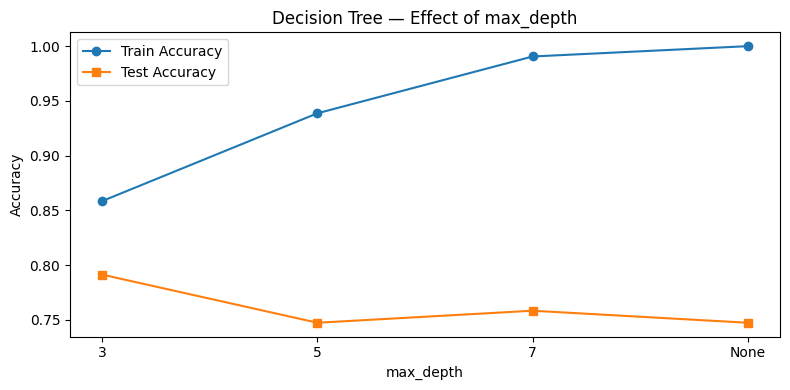

In [47]:
#5. Efecto de max_depth
depths = [3, 5, 7, None]
results = []

for d in depths:
    model = DecisionTreeClassifier(criterion='gini',
                                   max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    results.append({'max_depth': str(d), 'train': tr, 'test': te})
    print(f"max_depth={str(d):4s} → Train: {tr:.4f} | Test: {te:.4f}")

# Graficar
res_df = pd.DataFrame(results)
x = range(len(res_df))
plt.figure(figsize=(8, 4))
plt.plot(x, res_df['train'], marker='o', label='Train Accuracy')
plt.plot(x, res_df['test'],  marker='s', label='Test Accuracy')
plt.xticks(x, res_df['max_depth'])
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Effect of max_depth')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
#6. Mejor modelo — usar depth=5 (balance overfitting)
best_dt = DecisionTreeClassifier(criterion='gini',
                                  max_depth=5, random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.88      0.79        49
     Disease       0.81      0.60      0.68        42

    accuracy                           0.75        91
   macro avg       0.76      0.74      0.74        91
weighted avg       0.76      0.75      0.74        91



## 8. K-Fold Cross Validation

A single train/test split can be influenced by how the data was divided.
To verify that the model performance is consistent and not the result of a lucky split,
K-Fold Cross Validation is applied.

The training data is divided into 5 folds. In each iteration, one fold is used
as the validation set and the remaining four are used for training.
This process repeats 5 times, each time using a different fold for validation.

The final result is the mean accuracy across all 5 folds, along with the
standard deviation which indicates how stable the model is.

A low standard deviation means the model performs consistently regardless
of how the data is split.

In [49]:

# Use StratifiedKFold to preserve class distribution in each fold
# This is important for classification problems, as the TA explained in class
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Apply cross-validation on the best model using the training set only
cv_scores = cross_val_score(best_dt, X_train, y_train,
                             cv=skf, scoring='accuracy')

print("Cross-validation scores per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean accuracy:       {cv_scores.mean():.4f}")
print(f"Standard deviation:  {cv_scores.std():.4f}")

Cross-validation scores per fold:
  Fold 1: 0.7907
  Fold 2: 0.7442
  Fold 3: 0.7857
  Fold 4: 0.7381
  Fold 5: 0.7619

Mean accuracy:       0.7641
Standard deviation:  0.0212


#### CMT:Por qué StratifiedKFold y no KFold normal?
La TA mostró StratifiedKFold específicamente para clasificación — garantiza que cada fold tenga la misma proporción de clases (54% sin enfermedad, 46% con enfermedad) en lugar de hacer un split puramente aleatorio. Es exactamente lo que explica el slide de "Stratified K Fold Cross Validation" que te mandó la TA.

## 9. Confusion Matrix

While K-Fold Cross Validation confirmed that the model performs consistently
across different data splits, the confusion matrix provides a detailed view
of the specific errors made on the final test set.

The confusion matrix shows the number of correct and incorrect predictions for each class.

- **True Positives (TP)**: disease correctly predicted as disease
- **True Negatives (TN)**: no disease correctly predicted as no disease
- **False Positives (FP)**: no disease incorrectly predicted as disease
- **False Negatives (FN)**: disease incorrectly predicted as no disease

In a clinical setting, False Negatives are the most critical error,
as they represent patients with heart disease who were not identified by the model.

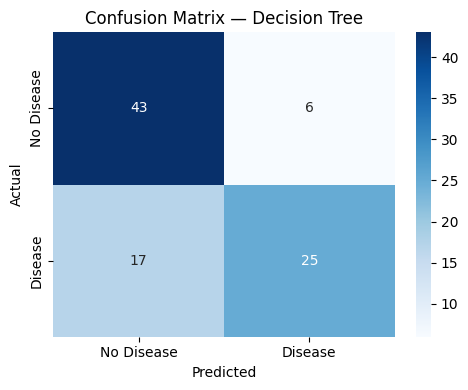

In [50]:
#7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

## 10. Feature Importance

Feature importance indicates how much each variable contributed to the model's decisions.

Higher values mean the feature was used more frequently and at higher levels of the tree,
making it more influential in the classification.

This analysis helps us understand which medical indicators are most relevant
for predicting heart disease in this dataset.

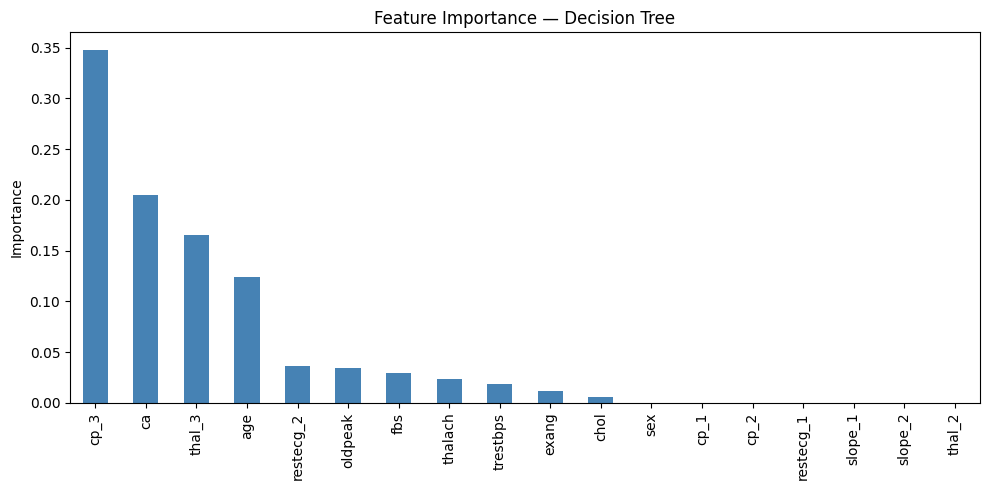

cp_3         0.347710
ca           0.204323
thal_3       0.165133
age          0.123834
restecg_2    0.036022
oldpeak      0.034468
fbs          0.029751
thalach      0.022952
trestbps     0.018040
exang        0.011589
chol         0.006179
sex          0.000000
cp_1         0.000000
cp_2         0.000000
restecg_1    0.000000
slope_1      0.000000
slope_2      0.000000
thal_2       0.000000
dtype: float64


In [51]:
#8. Feature Importance
importances = pd.Series(best_dt.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Decision Tree')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(importances)

## 10. Decision Tree Visualization

The decision tree structure is visualized to show how the model makes its decisions.

Each node displays:
- the feature and threshold used for splitting
- the Gini impurity at that node
- the number of samples
- the predicted class

The color intensity indicates class purity — darker nodes are closer to a single class.

This visualization is useful for interpreting the model and understanding
which features are used at the top levels of the tree.

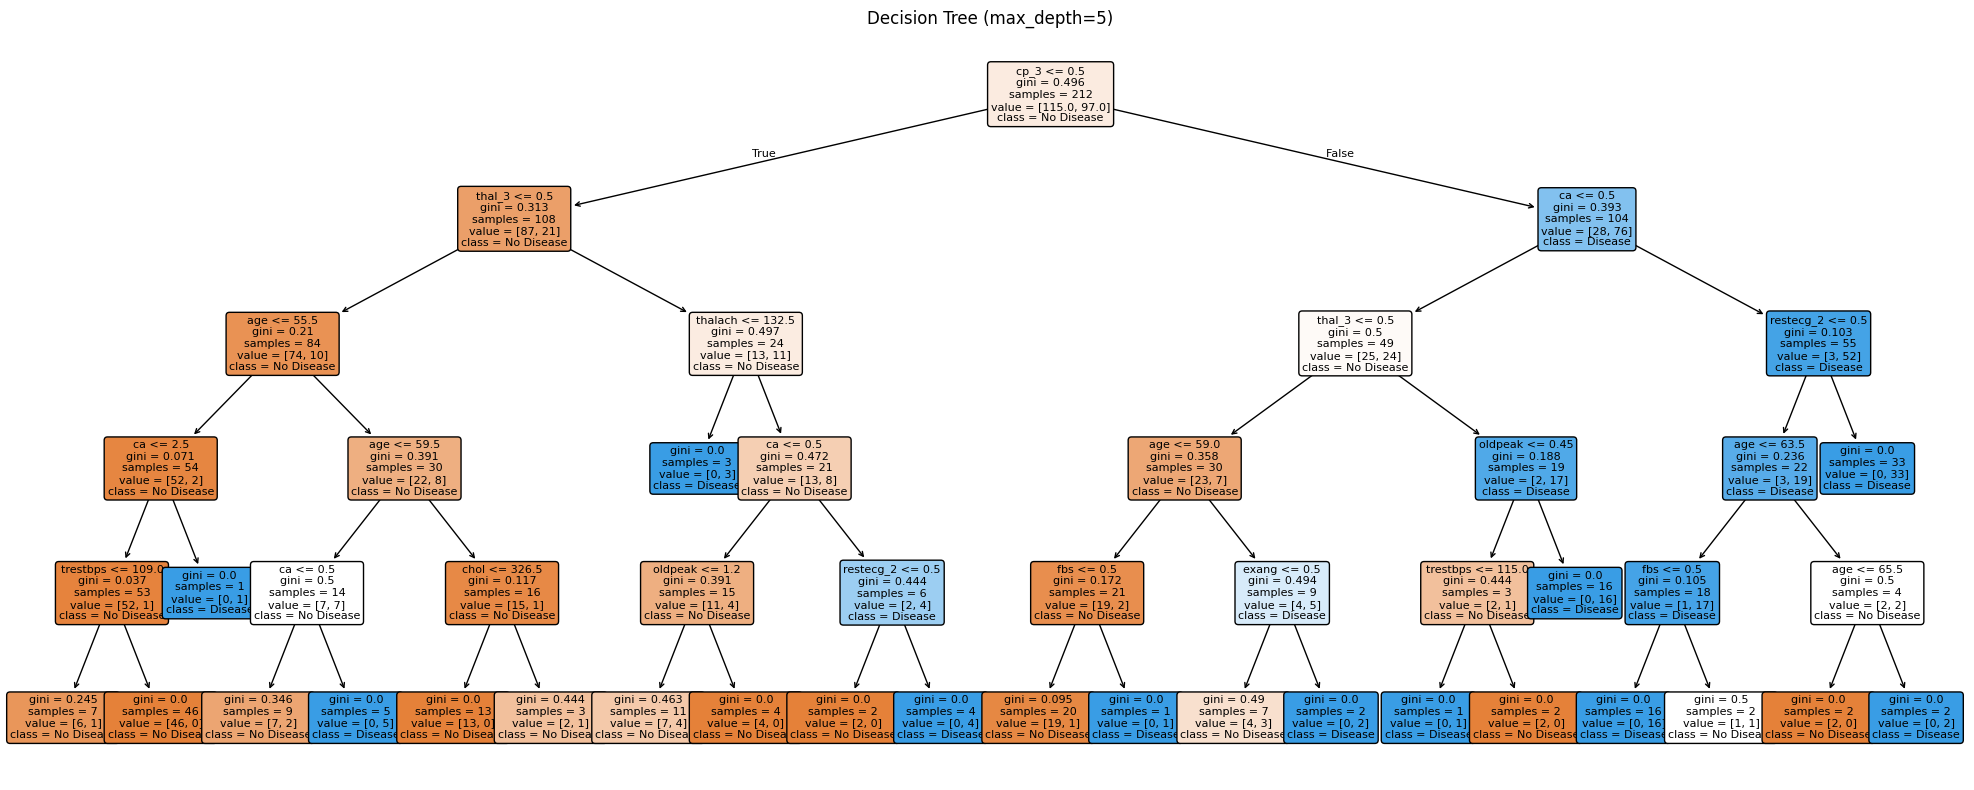

In [52]:
# 9. Visualización del árbol
plt.figure(figsize=(20, 8))
plot_tree(best_dt,
          feature_names=X_train.columns,
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (max_depth=5)')
plt.tight_layout()
plt.show()